# grahspj: Single-SED Example

This notebook shows a minimal end-to-end fit of one SED using `grahspj`.

Workflow:
- load one deterministic example from the Chimera benchmark dataset
- build a `FitConfig`
- run a MAP fit
- compare recovered stellar mass to the Chimera truth value
- generate a `pcigale`-style component SED plot with the photometry overlaid

## Prerequisites

This notebook assumes:
- you are running it from the `grahsp-run-jax/notebooks` directory
- `grahspj` dependencies are installed
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.benchmark import (
    build_chimera_fit_config,
    load_chimera_benchmark_dataset,
    select_chimera_subset,
)
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())

In [2]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

dataset = load_chimera_benchmark_dataset(project_root)
subset = select_chimera_subset(dataset, project_root)

# Use a more AGN-informative Chimera source for the tutorial instead of the
# first benchmark row, which is nearly host-dominated. Also require finite
# NIR photometry so the photometry-seeded priors are well behaved.
row = next(
    r for r in subset
    if float(r["chimera_QSO_weight"]) >= 1.0
    and all(np.isfinite(float(r[name])) for name in ("J_2mass", "H_2mass", "Ks_2mass", "IRAC1", "IRAC2"))
)

row["id"], row["chimera_QSO_weight"], row["redshift"], row["log_stellar_mass_truth"]

[benchmark] Loading Chimera photometry from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 270 benchmark rows


('014916.01+143816.5_700060_1', 1.0, 2.160900115966797, 10.2773)

## Build the fit configuration

The Chimera helper seeds a few important priors from the row photometry and redshift so the fit starts on a more reasonable flux scale. This model now also enables host-galaxy energy balance by default: stellar light absorbed by host dust is re-emitted in the infrared with the Dale et al. (2014) host dust templates. AGN type is a fixed config choice, not an inferred parameter. The AGN line model now follows the `GRAHSP` branch logic more closely: type `1` includes broad lines, Sy2 narrow lines, Fe II, and optional Balmer continuum; types `2` and `3` suppress Fe II and Balmer continuum. For this tutorial run, reduce the optimizer and sampler settings so the example finishes more quickly. Increase them later if you want a stronger fit.


In [3]:
cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
cfg.inference.map_steps = 200
cfg.inference.learning_rate = 5e-3
cfg.inference.num_warmup = 200
cfg.inference.num_samples = 200

print("Photometry-seeded prior centers:")
print("  log_stellar_mass:", cfg.prior_config.get("log_stellar_mass"))
print("  log_agn_amp:", cfg.prior_config.get("log_agn_amp"))
print("Host energy balance enabled:", cfg.galaxy.use_energy_balance)
print("Initial dust_alpha:", cfg.galaxy.dust_alpha)
print("Fixed AGN type:", cfg.agn.agn_type)
print("Set `cfg.agn.agn_type = 2` or `3` before fitting to compare Sy2/LINER branches.")

cfg


Photometry-seeded prior centers:
  log_stellar_mass: {'loc': 12.0, 'scale': 0.7}
  log_agn_amp: {'loc': 93.2468486081733, 'scale': 2.0}
Host energy balance enabled: True
Initial dust_alpha: 2.0
Fixed AGN type: 1
Set `cfg.agn.agn_type = 2` or `3` before fitting to compare Sy2/LINER branches.


FitConfig(observation=Observation(object_id='014916.01+143816.5_700060_1', redshift=2.160900115966797, redshift_err=0.0, ra=None, dec=None, apply_mw_deredden=False), photometry=PhotometryData(filter_names=['u_sdss', 'r_sdss', 'i_sdss', 'z_sdss', 'J_2mass', 'H_2mass', 'Ks_2mass', 'IRAC1', 'IRAC2'], fluxes=[0.06089159846305847, 0.35920968651771545, 0.3431943655014038, 0.45071807503700256, 0.3758549094200134, 0.48371297121047974, 0.5712677836418152, 0.59767085313797, 1.176833987236023], errors=[0.0034985800739377737, 0.005650961771607399, 0.013814584352076054, 0.010464748367667198, 0.041283171623945236, 0.058126505464315414, 0.08042063564062119, 0.018276650458574295, 0.03612200915813446], is_upper_limit=[False, False, False, False, False, False, False, False, False]), filters=FilterSet(curves=[FilterCurve(name='IRAC1', wave=array([29750., 30000., 30250., 30500., 30750., 31000., 31250., 31500.,
       31750., 32000., 32250., 32500., 32750., 33000., 33250., 33500.,
       33750., 34000., 34

In [4]:
fitter = GRAHSPJ(cfg)
fit_result = fitter.fit(
    fit_method="optax+nuts",
    prior_config=cfg.prior_config,
    dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=False,
    save_fig=False,
    save_result=False,
    progress_bar=True,
)

summary = fit_result["summary"]
recovered_logm = fitter.recovered_log_stellar_mass()
truth_logm = row["log_stellar_mass_truth"]

print("object_id:", row["id"])
print("chimera_QSO_weight:", row["chimera_QSO_weight"])
print("truth log stellar mass:", truth_logm)
print("recovered log stellar mass:", recovered_logm)
print("residual:", recovered_logm - truth_logm)
summary


sample: 100%|██████████| 100/100 [05:39<00:00,  3.39s/it, 255 steps of size 7.47e-03. acc. prob=1.00]


object_id: 014916.01+143816.5_700060_1
chimera_QSO_weight: 1.0
truth log stellar mass: 10.2773
recovered log stellar mass: 11.284398005471628
residual: 1.0070980054716276


{'absolute_flux_scale_logprior_median': -0.22680233496831204,
 'agn_fluxes_median': [0.10829962488481856,
  0.2309482085436507,
  0.27218201761103655,
  0.3085720747877223,
  0.3679362333232843,
  0.41917516180400427,
  0.47955580170827317,
  0.6901373293520525,
  0.9499566347549953],
 'agn_obs_sed_median': [0.0,
  2.610844317527894e-19,
  2.6108339792632584e-19,
  2.608875599381951e-19,
  2.6043684845275177e-19,
  2.598924878452356e-19,
  2.594245633202313e-19,
  2.5906302073362086e-19,
  2.587617383561715e-19,
  2.5848192265158113e-19,
  2.582708473675968e-19,
  2.5810321401197306e-19,
  2.5793317001516465e-19,
  2.577607234348643e-19,
  2.575861169356513e-19,
  2.574117698195052e-19,
  2.5725350660083864e-19,
  2.5717267627746275e-19,
  2.572851184655222e-19,
  2.5759751436320063e-19,
  2.577809087531829e-19,
  2.5746007532299027e-19,
  2.5677372243864024e-19,
  2.5615564618070685e-19,
  2.557677333574293e-19,
  2.555158544986505e-19,
  2.5530396595169316e-19,
  2.5509760842979257e-

## Generate a component SED plot

`fit()` defers predictive model evaluation until you explicitly request it. Calling `plot_sed()` will trigger the predictive path and draw the total model, the stellar host, the host dust IR re-emission, and the AGN sub-components together with the observed photometry. Zero-only AGN branches are omitted from the plot automatically, so Sy2/LINER fits stay uncluttered.


/Users/colinburke/research/grahspj/src/grahspj/plotting.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


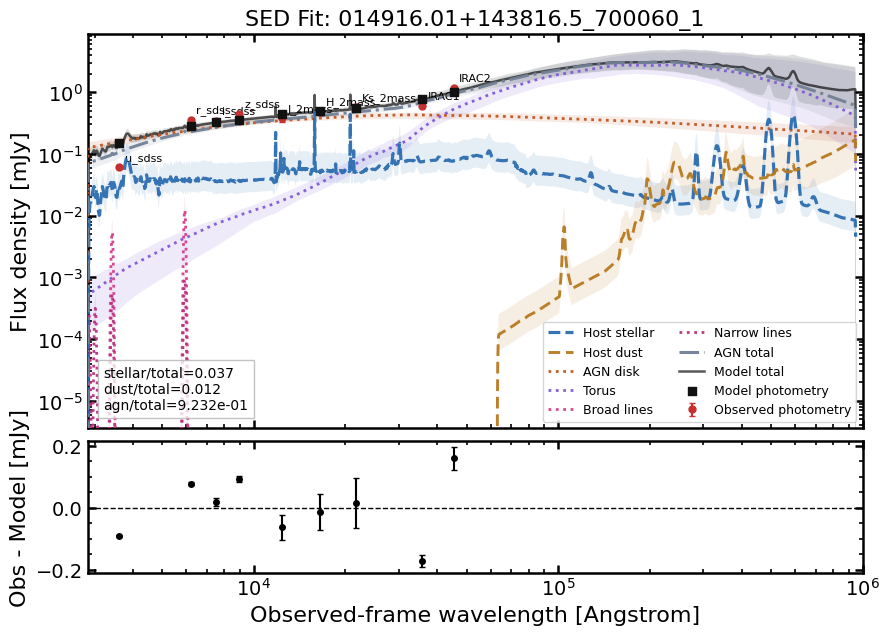

filter, eff_wave_A, obs_mJy, model_mJy, host_stellar_mJy, host_dust_mJy, agn_mJy
('u_sdss', np.float64(3614.373573958611), 0.06089159846305847, np.float64(0.13000057028215312), np.float64(0.031229458619045927), np.float64(0.0), np.float64(0.09877111166310722))
('r_sdss', np.float64(6205.832237243061), 0.35920968651771545, np.float64(0.2793225233517082), np.float64(0.03463772901085313), np.float64(0.0), np.float64(0.24468479434085497))
('i_sdss', np.float64(7525.622462977008), 0.3431943655014038, np.float64(0.32571009949916013), np.float64(0.03404348755314253), np.float64(0.0), np.float64(0.2916666119460176))
('z_sdss', np.float64(8947.384740828762), 0.45071807503700256, np.float64(0.36702503788098784), np.float64(0.0338368156988902), np.float64(0.0), np.float64(0.33318822218209776))
('J_2mass', np.float64(12407.991602068245), 0.3758549094200134, np.float64(0.454043125780042), np.float64(0.05097127168935511), np.float64(0.0), np.float64(0.4030718540906868))
('H_2mass', np.float64(16513.

[('u_sdss',
  np.float64(3614.373573958611),
  0.06089159846305847,
  np.float64(0.13000057028215312),
  np.float64(0.031229458619045927),
  np.float64(0.0),
  np.float64(0.09877111166310722)),
 ('r_sdss',
  np.float64(6205.832237243061),
  0.35920968651771545,
  np.float64(0.2793225233517082),
  np.float64(0.03463772901085313),
  np.float64(0.0),
  np.float64(0.24468479434085497)),
 ('i_sdss',
  np.float64(7525.622462977008),
  0.3431943655014038,
  np.float64(0.32571009949916013),
  np.float64(0.03404348755314253),
  np.float64(0.0),
  np.float64(0.2916666119460176))]

In [5]:
pred = fitter.predict()
fig = fitter.plot_sed(show=True)

model_flux = np.asarray(pred["pred_fluxes"][0], dtype=float)
host_flux = np.asarray(pred["host_fluxes"][0], dtype=float)
dust_flux = np.asarray(pred["dust_fluxes"][0], dtype=float)
agn_flux = np.asarray(pred["agn_fluxes"][0], dtype=float)
phot_wave = np.asarray([flt.effective_wavelength for flt in fitter.context.filters], dtype=float)
dust_luminosity = float(np.median(np.asarray(pred["dust_luminosity"], dtype=float)))

component_table = [
    (name, wave, obs, model, host, dust, agn)
    for name, wave, obs, model, host, dust, agn in zip(
        cfg.photometry.filter_names,
        phot_wave,
        cfg.photometry.fluxes,
        model_flux,
        host_flux,
        dust_flux,
        agn_flux,
    )
]
print("filter, eff_wave_A, obs_mJy, model_mJy, host_stellar_mJy, host_dust_mJy, agn_mJy")
for row_vals in component_table:
    print(row_vals)

print("dust luminosity [W]:", dust_luminosity)
print("stellar / total model:", float(np.sum(host_flux) / np.maximum(np.sum(model_flux), 1e-30)))
print("dust / total model:", float(np.sum(dust_flux) / np.maximum(np.sum(model_flux), 1e-30)))
print("agn / total model:", float(np.sum(agn_flux) / np.maximum(np.sum(model_flux), 1e-30)))

component_table[:3]


## Next steps

- compare the printed host and AGN model photometry against the observed points band by band
- if the model is still too host-dominated, tighten `cfg.prior_config["log_stellar_mass"]` and/or broaden `cfg.prior_config["log_agn_amp"]`
- increase `cfg.inference.map_steps`, `num_warmup`, and `num_samples` for a stronger posterior fit
- use `fitter.save(...)` to write a posterior bundle
- swap in your own photometry by constructing a custom `FitConfig`